16
Family count :  0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: FamilyCount, Length: 891, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    object 
 5   Age              714 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Cabin            204 non-null    object 
 11  Embarked         889 non-null    object 
 12  HasCabin         891 non-null    bool   
 13  FamilyCount      891 non-null    int6

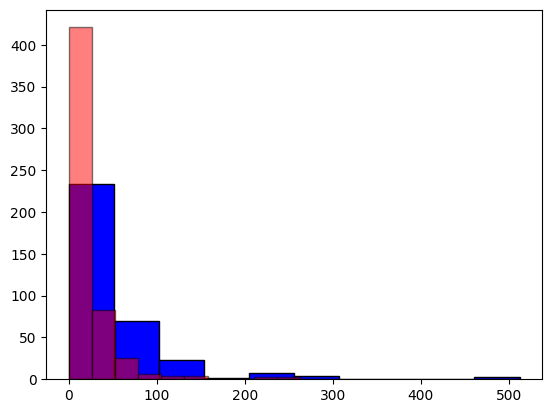

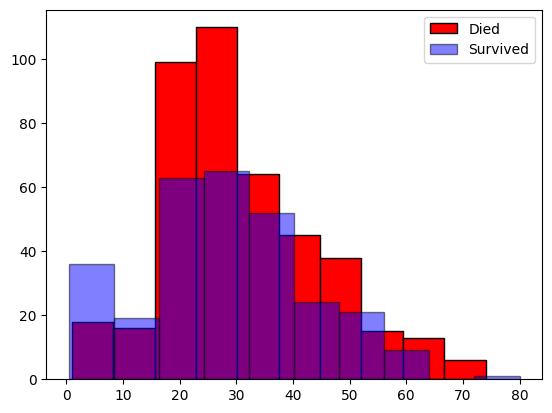

############################################################
############################################################


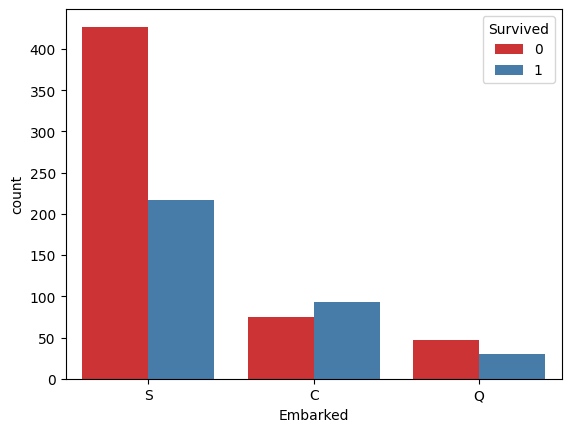

############################################################
Family count survival rate : 


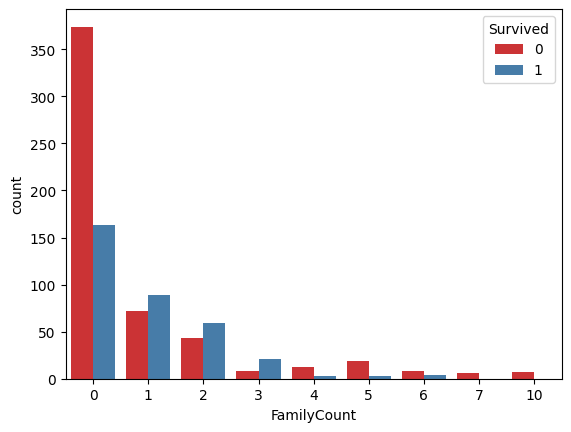

############################################################


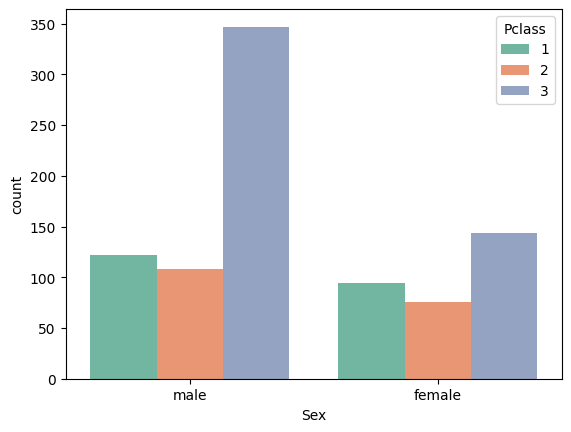

############################################################


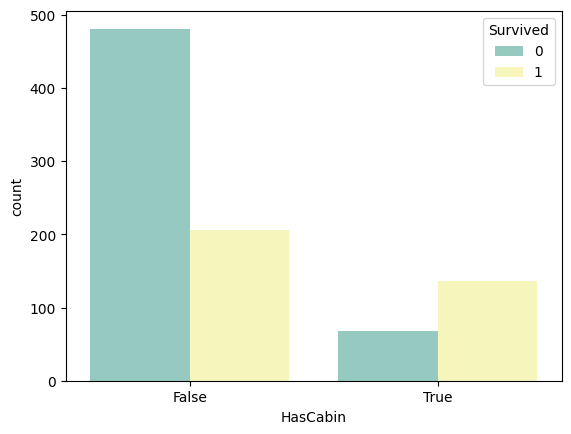

############################################################
############################################################


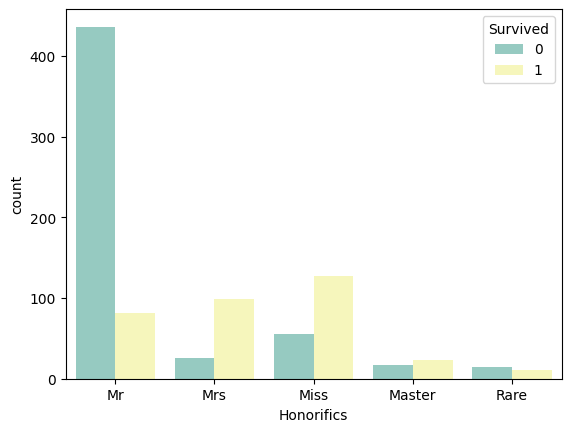

############################################################
############################################################


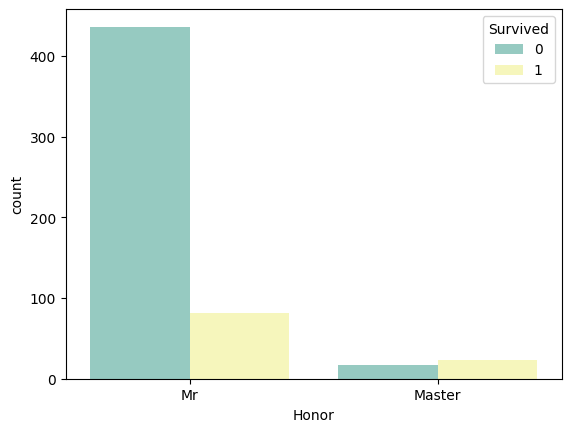

SUrvival rate of adult man vs young boys :
############################################################
Fare to class
1      71.2833
3      53.1000
6      51.8625
11     26.5500
23     35.5000
        ...   
871    52.5542
872     5.0000
879    83.1583
887    30.0000
889    30.0000
Name: Fare, Length: 216, dtype: float64
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  FamilyCount  Is

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path().cwd()
DATA_PATH = BASE_DIR.parent / "data" / "train.csv"
# BASE_DIR_TEST = Path(__file__).resolve().parent if "__file__" in locals() else Path().cwd()
DATA_PATH_TEST = BASE_DIR.parent / "data" / "test.csv"
data = pd.read_csv(DATA_PATH)

data['HasCabin'] = data["Cabin"].notna()
# data["HasFamily"] = ((data["Parch"] > 0) | (data["SibSp"] > 0)).astype(int)
data["FamilyCount"] = data["Parch"]+ data["SibSp"] 
data["Honor"] = data["Name"].str.extract(",\s*(\w+)\.")
FamilyGroups = ["Alone" , "Small" , "Large"]
data["FamilySizeGroup"] = np.select([data["FamilyCount"] == 0 , ((data["FamilyCount"] > 0) & (data["FamilyCount"] <= 3 )) , data["FamilyCount"] > 3 ] , FamilyGroups , default="Alone")

# print(data["FamilySizeGroup"])
print("="*60)

print(data["Honor"].nunique())
print("="*60)
print("Family count : " ,data["FamilyCount"])
print("="*60)

# data["Embarked"]= nominal_encoder.fit_transform(data["Embarked"])
print(data.info(memory_usage="deep"))
print("="*60)
print(data.groupby("Sex")["Survived"].mean())
print("-"* 100)
print(data.groupby("HasCabin")["Survived"].mean())
print("-"* 100)
# print(data.groupby("Pclass")["Survived"].mean())
print("-"* 100)

print(f'Survival rate of Female based on Pclass: {data[data["Sex"] == 1].groupby("Pclass")["Survived"].mean()}')


plt.hist(data[(data["Survived"] == 1) ]["Fare"]   ,  color="blue" , edgecolor='black' , label="Lived")
plt.hist(data[(data["Survived"] == 0) ]["Fare"]   ,  alpha=0.5 ,  color="red" , edgecolor='black' , label="Died")

plt.show()

data["Name"].str.split()
data["Honorifics"] = np.where(data["Honor"].str.contains("Mrs|Miss|Mr|Master" ) , data["Honor"] ,  "Rare" )

# Clean, explicit binary interaction feature
data['Is_HighStatus_Woman'] = ((data['Sex'] == "female") & (data['Pclass'] <= 2)).astype(int)

plt.hist(data[data["Survived"] == 0]["Age"]   ,  color="red" , edgecolor='black' , label="Died")
plt.hist(data[data["Survived"] == 1]["Age"]  , alpha=0.5 , color="blue" , edgecolor='black' , label="Survived")
plt.legend(loc='upper right')

plt.show()

print("#"*60)


print("#"*60)
sns.countplot(data=data, x="Embarked", hue="Survived", palette="Set1")
plt.show()
print("#"*60)
print("Family count survival rate : ")

sns.countplot(data=data, x="FamilyCount", hue="Survived", palette="Set1")
plt.show()
print("#"*60)
sns.countplot(data=data , x="Sex" , hue="Pclass" , palette="Set2")
plt.show()

print("#"*60)

sns.countplot(data=data , x="HasCabin" , hue="Survived" , palette="Set3")
plt.show()
print("#"*60)
print("#"*60)


# sns.countplot(data=data , x="HasFamily" , hue="Survived" , palette="Set3")
# plt.show()
# print("#"*60)
# print("#"*60)

sns.countplot(data=data , x="Honorifics" , hue="Survived" , palette="Set3")
plt.show()

print("#"*60)
print("#"*60)



sns.countplot(data=data[(data["Honor"] == "Mr") | (data["Honor"] == "Master")  ], x="Honor" , hue="Survived" , palette="Set3")
plt.show()

print("SUrvival rate of adult man vs young boys :")
# data.groupby("Honorifics")["Survived"].mean()
print("#"*60)

print("Fare to class")
print(data.loc[data["Pclass"] == 1 , "Fare"])
plt.show()

# sns.countplot(data=data , x="Honorfics" , hue="Survived" , palette="Set3")
# plt.show()
# print("#"*60)

print(data.describe())
y = data["Survived"]
X = data.drop(columns=["Survived"])
# X.isna().sum()


# plt.scatter(X["Age"], X["SibSp"])

# plt.scatter(X["Parch"] , y)

# X["SibSp"].plot.kde()
# X["Parch"].plot.kde()
# X["Pclass"].plot.kde()


Selected_cols = ["Embarked" , "Age" , "HasCabin" , "Honorifics" , "Sex" , "Pclass" , "FamilySizeGroup" , "Is_HighStatus_Woman" , "Fare"]
X2 = X[Selected_cols].copy()



num_cols = ["Age", "Fare"]
cat_cols = [
    "Embarked",
    "HasCabin",
    "Honorifics",
    "Sex",
    "Pclass",
    "FamilySizeGroup",
    "Is_HighStatus_Woman",
]

num_transformer = Pipeline([
    
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Selected_Data = pd.get_dummies(Selected_Data , columns=["Embarked"] , drop_first= True)

cat_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot" , OneHotEncoder(handle_unknown="ignore")
)
])



preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)

full_pipeline = Pipeline([("preprocessor" , preprocessor) , ("classifier", LogisticRegression(max_iter=500))])
# model = LogisticRegression(max_iter=200);

skf = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)

scores = cross_val_score(full_pipeline , X2 , y  , cv=skf ,scoring="accuracy")
print(f'scores :  {scores}')
print(f'avg score :  {scores.mean()}')